# Multi Agent Systems: A1 - Brownian Motion
#### Deadline: 16-04-2026, 12:00

You may hand in the assignment up to one day late, in which case the assignment grade will be capped at 8. For any extensions please contact Luco Buise.

Hand in the notebook file on Brightspace, name your file as follows: $\textbf{A1_yourname.ipynb}$

Studentname: ... \
Studentnumber:  ...


$\textit{Don't forget to label your axis and give your graphs titles!}$

### AI Disclaimer

There is no need to use AI such as LLM based chatbots in the assignments (unless
explicitly said otherwise). While the use of AI is not forbidden, whenever AI is used,
you are expected to report what model was used, where was it used in the assignment,
how, and for what purpose. Use the cell below to summarise your AI use. 

**Also note it if you did not use AI! If so, we expect to see absolutely no signs of AI use in your assignment.**

---
#### FILL THIS IN
**Did you use AI for this assignment?** [yes/no]

**Model used:** e.g. *Claude AI*

**Used in:** e.g. *questions 1.1, 3.1*

**Why:** e.g. *To help me create plots and save time scouring documentation*

---

## Part 0: Integration by Hand

Many of the dynamical systems you will be introduced to and work with are described by equations that describe a change of state over time (e.g. $\dfrac{dx}{dt}$). Sometimes these can be analytically solved, but often we will approximate them using stepwise Euler Integration. The following questions allow you to get a feeling for how this works, and get you reacquainted with integration.

**WE ASK YOU TO DO THE QUESTIONS IN PART 0 BY HAND AND UPLOAD A PHOTO OF YOUR NOTES TOGETHER WITH THE ASSIGNMENT!**

#### 0.1 - Euler Integration (0.5 points)

In our systems, we'd ideally have $dt$ as small as possible to approximate the dynamics. Yet too small can take too much time to compute with diminishing return on accuracy. Too high of a $dt$ can be largely inaccurate. 

Suppose you had $\int_{-3}^3 e^{-x^2} dx$. Make a table with columns $x$, $f(x)$, and $f(x)dx$ (see below), evalutate their values at every $x$ in the integration range for the two $dx$ below, and sum the final column to approximate the integral. Round results to 2nd decimal.
1. $dx=1$
2. $dx=0.5$
3. $dx=0.25$

Example for $dx = 0.5$

| x  | f(x) | f(x)dx  |
| --- | --- | --- |
| -3 | 0.00012 | 0.00006 |
| -2.5 | 0.0019 | 0.00097 |
| -2 | ... | ... |

<center>
<img src= gaussianIntegral.jpg width = 300px> </img>
</center>

#### 0.2 -  Integration (0.5 points)

Calculate the following integral analytically by hand (hint: $f(x) = e^{-x^2}$ is a Gaussian function):

$\int_{-\infty}^{\infty} e^{-x^2} dx$

How does the answer compare to the integration results in 0.1.1, and 0.1.2, and 0.1.3?

#### 0.3 -  Integration cont. (0.5 bonus points)**

As practice, calculate the following integrals by hand:
1. $\int_{-\infty}^{\infty} xe^{-x^2} dx$
2. $\int_{-\infty}^{\infty} x^2e^{-x^2} dx$


## Part 1: Brownian Motion

In the class we touched on a basic version of Brownian motion where a particle (agent's) 2D position, $\vec{r}=\left(x,y\right)$, evolves in time according to the following equation

$$\vec{v}\equiv \frac{d \vec{r}}{dt} \equiv \dot{\vec{r}} = A \vec{R}\left(t\right)$$

where $\vec{R}\left(t\right) = \left(R_x\left(t\right),R_y\left(t\right)\right)$ is an implicit stochastic function (with components $R_x$, $R_y$), and $A$ is a constant. It acts as a noise term which we do not know exactly, but we know its moments, such at the average, standard deviation and so on. In the following worksheet you will have the opportunity to simulate such agents, in preparation for active, stochastic agents.

### Futher reading

You can read more about Brownian Motion here 

https://en.wikipedia.org/wiki/Langevin_equation

and
https://en.wikipedia.org/wiki/Brownian_motion

In [1]:
# these are the only imports necessary for this assignment
import numpy as np
import matplotlib.pyplot as plt

#### 1.1 - 1D Brownian motion (0.5 points)

Simulate a Brownian particle in 1 dimension and plot its movement. Plot its position on the y-axis, and the time one the x-axis. Use Euler integration - i.e. $x_{n+1} = x_n + \Delta_w$. Here, $\Delta_w$ represents the discretized Wiener process, which we can sample from a Normal distribution with mean 0 and variance $\Delta_t$.

Text(0.5, 1.0, 'Brownian motion of a single particle')

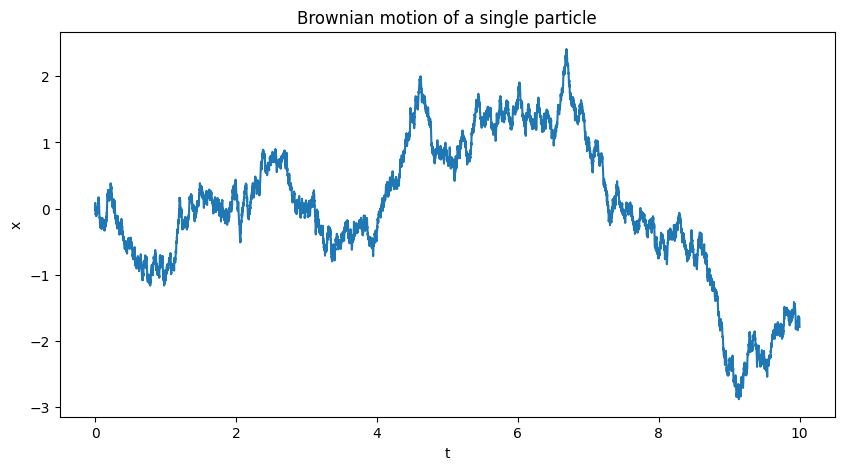

In [14]:
# define initial conditions
x_0 = 0

# define timesteps and time
dt = 0.001
t_0 = 0
t_1 = 10
t = np.arange(t_0, t_1, dt)

# initialize the array that will be filled in with the positions of the particle
n = int(t_1 / dt)
Xs = np.zeros(n + 1)

# initialize initial condition of trajectory
Xs[0] = x_0

# simulate Brownian motion
for i, t_ in enumerate(t):
    Xs[i + 1] = Xs[i] + np.random.normal(0, np.sqrt(dt))

# plotting code (don't forget the title and axis labels!)
plt.figure(figsize = (10,5))
plt.plot(t, Xs[:-1])
plt.xlabel("t")
plt.ylabel("x")
plt.title("Brownian motion of a single particle")

#### 1.2 - 2D Brownian Motion (0.5 point)

Now use what you've learned in the previous section to expand the Brownian motion to 2 dimensions. Simulate the trajectory of a Brownian particle, and plot its trajectory. Now use the plot axis two represent the 2 dimensions of movement.

Text(0.5, 1.0, '2D Brownian motion of a single particle')

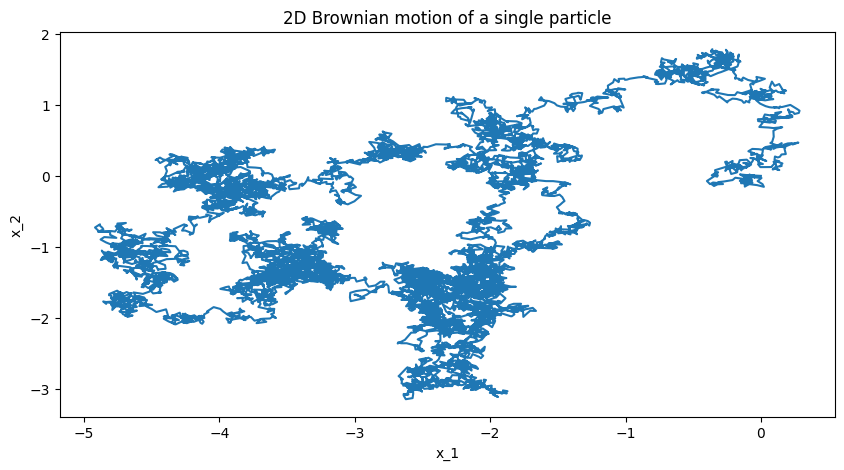

In [24]:
# define initial conditions
x1_0, x2_0 = 0, 0

# Initialise data
Xs_2d = np.zeros((n+1, 2))
Xs_2d[0] = [x1_0, x2_0]

# simulate Brownian motion
for i, t_ in enumerate(t):
    Xs_2d[i + 1] = Xs_2d[i] + np.random.normal(np.zeros(Xs_2d[i].shape), np.sqrt(dt))
    
# plotting code (don't forget the title and axis labels!)
plt.figure(figsize = (10,5))
plt.plot(Xs_2d[:, 0], Xs_2d[:, 1])
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title("2D Brownian motion of a single particle")

#### 1.3 - Multiple 2D Brownian Particles (0.5 points)

Finally, simulate the trajectory of 5 non-interacting Brownian particles and plot them all in the same graph. Give each a different colour and decrease the linewidth to avoid clutter. Avoid duplicate code!

Text(0.5, 1.0, '2D Brownian motion of a 5 particles')

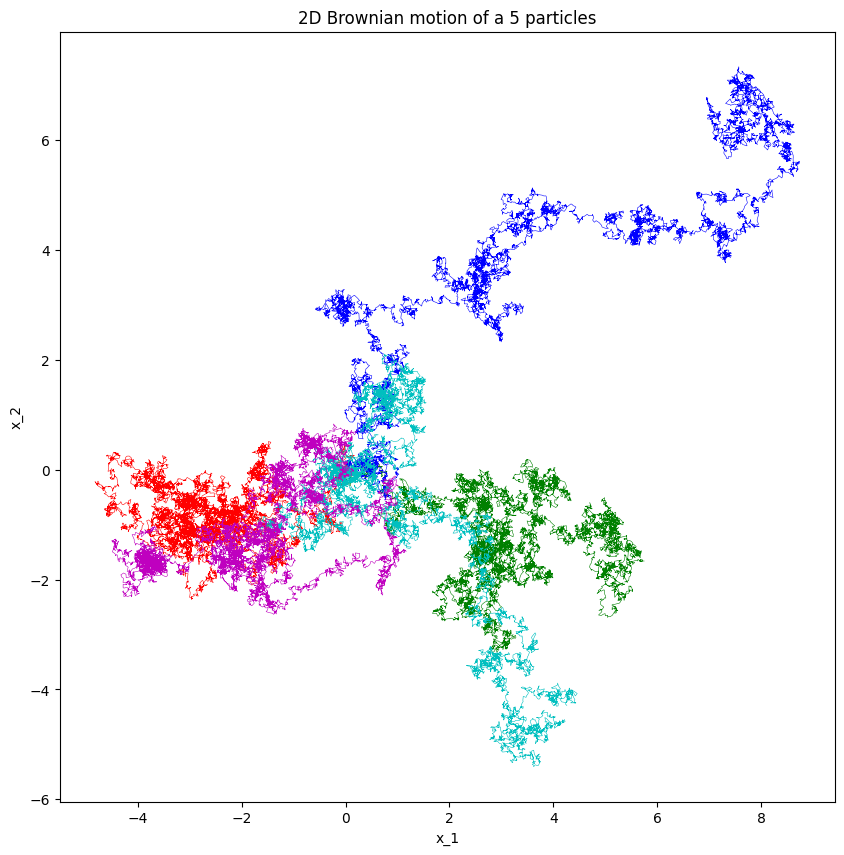

In [31]:
# YOUR CODE HERE
# define initial conditions
x1_0, x2_0 = 0, 0

n_particles = 5
# Initialise data
Xs_2d_batch = np.zeros((5, n+1, 2))
Xs_2d_batch[:, 0] = [x1_0, x2_0]

# simulate Brownian motion
for i, t_ in enumerate(t):
    Xs_2d_batch[:, i + 1] = Xs_2d_batch[:, i] + np.random.normal(np.zeros(Xs_2d_batch[:, i].shape), np.sqrt(dt))

# plotting code (don't forget the title and axis labels!)
colors = ["r", "g", "b", "c",  "m"]
plt.figure(figsize = (10,10))
for i in range(Xs_2d_batch.shape[0]):
    plt.plot(Xs_2d_batch[i, :, 0], Xs_2d_batch[i, :, 1], label=f"particle {i + 1}", c=colors[i], linewidth=0.4)
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title("2D Brownian motion of a 5 particles")

#### 1.4 - Probability Density of Brownian movement (1 point)

We want to figure out how the movement of the particles is distributed. Pick one of the particles you simulated and do the following:
* Compute the $x$ and $y$ displacement for every step
* Compute the magnitude of the displacement $\Delta r$ at every step (Pythagoras' theorem)
* Compute the magnitude of the displacement every 10 step (shift the original values)
* Plot the probability distribution for the magnitude of the displacement at every 10 steps (you can use a histogram)
* Plot a heatmap of the two-dimensional probability distribution, $P(\Delta x, \Delta y)$ of having a step $\Delta x$ and $\Delta y$ in $x$ and $y$ respectively
* Compute and print the mean and standard deviation for the distributions of $\Delta x, \Delta y$ and $\Delta r$ at 1 step and at 10 steps

Comment on these values and on the plots, do they make sense? Why or why not?

In [ ]:
# YOUR CODE HERE

$\textbf{YOU TEXT ANSWER HERE}$

## Part 2 - Simulating an Active Brownian Particle (ABP)

A Brownian particle is a very basics description for an agent. Adding some form of self propulsion makes the stochastic agent more "lively", as seen in natural and robotic swarms.

The equations of motion for an Active Brownian Particle are:

$\dot{\vec{v}} = v_0 \hat{e}$ \
$\dot{\theta} = AR\left(t\right)$

In 2D, $\hat{e}$ is a unit orientation vector given by the angle $\theta$ relative to the $x$ axis.

#### 2.1 - 2D Active Brownian Particle (1.5 points)

We will now build upon what we just did, but rather than letting the movement of the particle be completely determined by a stochastic process (the Wiener process), the particle will now also be able to propulse itself forward. However, for this we will need an additional parameter that describes the particles orientation. In the 2 dimensional case, we can use a polar angle $\theta$ to parametrize the unit vector $\hat{e}$ that describes the orientation, so that $\hat{e} = [cos(\theta), sin(\theta)]$. The change of $\theta$ is also a stochastic process determined by a normal distribution.

Multiplying this unit vector with the particle's velocity $v_0$ (which we will keep static for now) gives us the propulsion. We can now describe the particle's next state using the drift, which is the propulsion. Use the following two steps in your Euler integration:

$x_{n+1} = x_n + \Delta_t\hat{e}v_0$ \
$\theta_{n+1} = \theta_n + \Delta_w$ with $\Delta_w \sim N(0, \sqrt{\Delta_t}2)$

In [ ]:
# define initial conditions
x1_0, x2_0 = 0, 0
theta_start = 0

# YOUR CODE HERE

#### 2.2 - Multiple 2D APBs (1 point)

Like before, simulate and plot 5 non-interacting APBs. Colour them differently and avoid clutter! Change the noise intensity of the orientation, try small noise, intermediate noise, and large noise.
What do the trajectories look like for different noise intensities?

In [ ]:
# YOUR CODE HERE

$\textbf{YOU TEXT ANSWER HERE}$

#### 2.3 - PDF of ABP movement (1 point)

Follow the same steps as you did in 1.4, but now for one of the ABPs you simulated. Comment on all the differences you notice with the values and plots you got for 1.4. What are the differences? Can you explain why they differ in this particular way?

In [ ]:
# YOUR CODE HERE

$\textbf{YOU TEXT ANSWER HERE}$

## Part 3 - Spatio-temporal evolution of a stochastic agent

So far you interacted with the individual trajectories, in the next part you will measure their mean time evolution.

An important quantity for measuring mean time evolution of mobile agents is their Mean Square Displacement (MSD). Which is given by:

$$ \rm{MSD} \equiv \left< r^2\left(\Delta t\right)\right>$$

#### 3.1 - MSD as function of noise (1 point)

Measure the mean square displacement of a Brownian particle for time delays up to N/3 of the length of the simulated trajectories for 5 different noise intensities. Plot the mean square displacement ($\Delta r^2\left(\Delta t\right)$) as a function of the time delay ($\Delta t$).

(remember to plot the axis, and a legend specifing the intensity of the noise) 

In [ ]:
# YOUR CODE HERE

#### 3.2 - MSD as function of noise (log scale) (1 point)

Measure the mean square displacement of an Active Brownian particle for time delays up to N/3 of the length of the simulated trajectories for 5 different noise intensities. Plot the mean square displacement ($\Delta r^2\left(\Delta t\right)$) as a function of the time delay ($\Delta t$) on a log - log scale.

In [ ]:
# YOUR CODE HERE

#### 3.3 - What does the MSD show? (1 point)

How did the increase of the noise change the MSD for 

1. Brownian Particle?
2. Active Brownian Particle?
3. How many regimes (regions of qualitatively different behaviours) can you identify for the BP?
4. How many regimes can you identify for the ABP?

$\textbf{YOU TEXT ANSWER HERE}$